# Semana 4 – Métodos de Regularización en Redes Neuronales
**Institución:** Universidad de Cundinamarca
**Programa:** Especialización en Inteligencia Artificial
**Objetivo:** Analizar y mitigar el sobreentrenamiento (overfitting) mediante técnicas de regularización (L2, Dropout, Early Stopping) utilizando el dataset de Diabetes.

##Importación y Preparación de Datos

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Configuración de semillas para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

# 1. Carga del Dataset de Diabetes
print("Cargando dataset...")
data = fetch_openml(name='diabetes', version=1, as_frame=True)
X = data.data
y = data.target

# 2. Preprocesamiento de Datos
# Imputación de posibles valores nulos (común en datasets médicos)
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Codificación de la variable objetivo (str a int)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# División en entrenamiento y prueba (estratificada para mantener proporciones)
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Escalamiento de características (fundamental para redes neuronales)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Dimensiones de entrenamiento: {X_train_s.shape}")

Cargando dataset...
Dimensiones de entrenamiento: (614, 8)


Definición de Modelos

In [2]:
# Función para crear modelos con diferentes configuraciones
def build_model(name, regularization=None, dropout_rate=0.0):
    """
    Construye un modelo base propenso a overfitting, al cual se le pueden
    inyectar técnicas de regularización para comparar el impacto.
    """
    model = keras.Sequential(name=name)
    model.add(layers.Input(shape=(X_train_s.shape[1],)))

    # Capa oculta 1 con o sin regularización L2
    if regularization == 'l2':
        model.add(layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.01)))
    else:
        model.add(layers.Dense(128, activation="relu"))

    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))

    # Capa oculta 2
    if regularization == 'l2':
        model.add(layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.01)))
    else:
        model.add(layers.Dense(64, activation="relu"))

    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))

    # Capa de salida para clasificación binaria
    model.add(layers.Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Parámetros de entrenamiento
EPOCHS = 150
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2

# Diccionario para almacenar el historial de cada modelo
histories = {}

##Entrenamiento - Base, L2 y Dropout

In [3]:
# 1. Modelo Base (Sin regularización)
print("Entrenando Modelo Base...")
model_base = build_model("Baseline")
histories['Base'] = model_base.fit(X_train_s, y_train, validation_split=VALIDATION_SPLIT,
                                   epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)

# 2. Modelo con Regularización L2 (Weight Decay)
print("Entrenando Modelo con L2...")
model_l2 = build_model("L2_Regularization", regularization='l2')
histories['L2'] = model_l2.fit(X_train_s, y_train, validation_split=VALIDATION_SPLIT,
                               epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)

# 3. Modelo con Dropout
print("Entrenando Modelo con Dropout...")
model_dropout = build_model("Dropout", dropout_rate=0.4)
histories['Dropout'] = model_dropout.fit(X_train_s, y_train, validation_split=VALIDATION_SPLIT,
                                         epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)

# 4. Modelo con Early Stopping (usando el modelo base)
print("Entrenando Modelo con Early Stopping...")
model_es = build_model("Early_Stopping")
early_stopping_cb = callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)
histories['Early_Stopping'] = model_es.fit(X_train_s, y_train, validation_split=VALIDATION_SPLIT,
                                           epochs=EPOCHS, batch_size=BATCH_SIZE,
                                           callbacks=[early_stopping_cb], verbose=0)

Entrenando Modelo Base...
Entrenando Modelo con L2...
Entrenando Modelo con Dropout...
Entrenando Modelo con Early Stopping...


##Visualización Comparativa

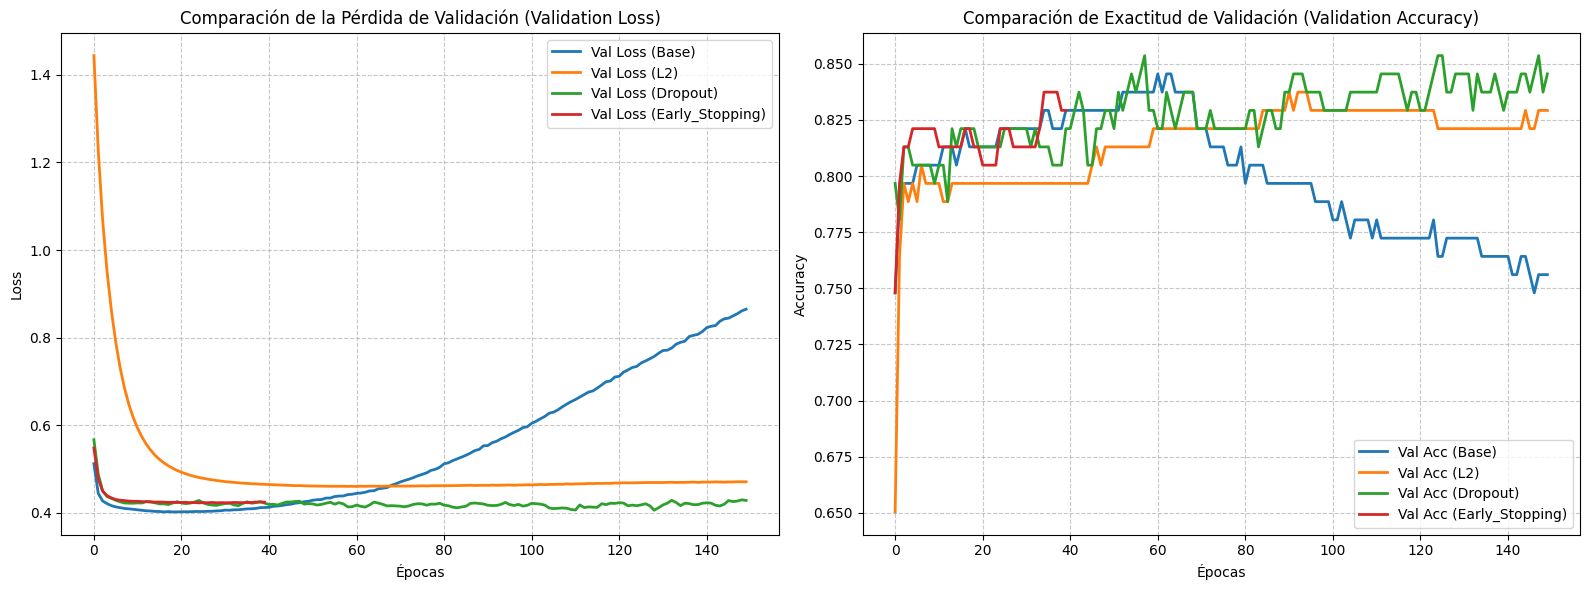

--- EVALUACIÓN EN EL CONJUNTO DE PRUEBA (TEST SET) ---
Base            -> Test Loss: 1.0139 | Test Accuracy: 0.7273
L2              -> Test Loss: 0.5563 | Test Accuracy: 0.7403
Dropout         -> Test Loss: 0.5729 | Test Accuracy: 0.7013
Early Stopping  -> Test Loss: 0.5127 | Test Accuracy: 0.7532


In [4]:
# Función para visualizar las métricas comparativas
def plot_comparisons(histories):
    plt.figure(figsize=(16, 6))

    # Gráfica de Pérdida (Loss)
    plt.subplot(1, 2, 1)
    for name, history in histories.items():
        val_loss = history.history['val_loss']
        plt.plot(val_loss, label=f'Val Loss ({name})', linewidth=2)
    plt.title('Comparación de la Pérdida de Validación (Validation Loss)')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # Gráfica de Exactitud (Accuracy)
    plt.subplot(1, 2, 2)
    for name, history in histories.items():
        val_acc = history.history['val_accuracy']
        plt.plot(val_acc, label=f'Val Acc ({name})', linewidth=2)
    plt.title('Comparación de Exactitud de Validación (Validation Accuracy)')
    plt.xlabel('Épocas')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

plot_comparisons(histories)

# Evaluación final en el conjunto de prueba
print("--- EVALUACIÓN EN EL CONJUNTO DE PRUEBA (TEST SET) ---")
for name, model in zip(['Base', 'L2', 'Dropout', 'Early Stopping'],
                       [model_base, model_l2, model_dropout, model_es]):
    loss, acc = model.evaluate(X_test_s, y_test, verbose=0)
    print(f"{name:15s} -> Test Loss: {loss:.4f} | Test Accuracy: {acc:.4f}")

##Análisis Técnico Final

## Análisis del Impacto de las Técnicas de Regularización

El sobreentrenamiento (overfitting) ocurre cuando el modelo captura el "ruido" de los datos de entrenamiento, aumentando su varianza y perdiendo capacidad de generalización. La regularización mitiga este problema de las siguientes maneras:

1. **Baseline (Sobreentrenamiento evidenciado):** En las gráficas, la curva de `val_loss` del modelo base comienza a aumentar drásticamente después de ciertas épocas, mientras que la pérdida de entrenamiento sigue cayendo. Esto es el indicador clásico de alta varianza.
2. **Regularización L2 (Penalización de Pesos):** Fuerza a que los pesos de la red sean pequeños, restringiendo la complejidad del modelo. Matemáticamente, añade el término $\lambda \sum w_i^2$ a la función de pérdida. Esto suaviza las fronteras de decisión y reduce drásticamente la varianza.
3. **Dropout:** Al "apagar" aleatoriamente un porcentaje de neuronas (ej. 40%) durante cada paso de entrenamiento, se evita la co-adaptación de las neuronas. La red se vuelve más robusta y generaliza mejor, funcionando como un ensamble (ensemble) implícito.
4. **Early Stopping:** Monitorea el `val_loss` y detiene el entrenamiento antes de que el modelo empiece a memorizar el ruido, restaurando los mejores pesos encontrados. Es la técnica más directa para cortar el incremento de la varianza temporal.

**Conclusión:** La regularización no siempre aumenta el *Accuracy* máximo, pero estabiliza la curva de pérdida de validación, garantizando que el modelo sea confiable ante datos no vistos.